# Stage 01 — FICO HELOC Data Exploration

This notebook loads Dataset 3 from the specified Hugging Face source, preserves an immutable local snapshot, and performs an initial data audit. No cleaning, preprocessing, splitting, modelling, or XAI is performed.

## 1. Setup and project paths

The notebook uses the project virtual environment and keeps HELOC data and artifacts isolated from the completed datasets.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import hashlib
import json

from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "heloc":
    PROJECT_ROOT = PROJECT_ROOT.parents[2]
elif PROJECT_ROOT.name == "ml":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "backend":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "backend" / "data" / "heloc" / "raw"
ARTIFACT_DIR = PROJECT_ROOT / "backend" / "artifacts" / "heloc"
PLOT_DIR = ARTIFACT_DIR / "plots"
for directory in [DATA_DIR, ARTIFACT_DIR, PLOT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_ID = "mstz/heloc"
TARGET = "is_at_risk"
SNAPSHOT_PATH = DATA_DIR / "heloc_raw.csv"

## 2. Hugging Face source and schema

The only acquisition call is `load_dataset("mstz/heloc")`. The returned DatasetDict is inspected before conversion to a DataFrame.

In [2]:
ds = load_dataset(SOURCE_ID)
print(ds)
print("Available splits:", list(ds.keys()))

split_inventory = pd.DataFrame([
    {"split": name, "rows": len(dataset), "columns": len(dataset.column_names)}
    for name, dataset in ds.items()
])
display(split_inventory)

if "train" not in ds:
    raise KeyError("The expected Hugging Face train split is unavailable.")

source_dataset = ds["train"]
raw_df = source_dataset.to_pandas()
feature_schema = pd.DataFrame([
    {"feature": name, "huggingface_type": str(feature_type)}
    for name, feature_type in source_dataset.features.items()
])
display(feature_schema)
print("Dataset builder:", source_dataset.info.builder_name)
print("Dataset name:", source_dataset.info.dataset_name)
print("Configuration:", source_dataset.info.config_name)
print("Version:", source_dataset.info.version)
print("Description available:", bool(source_dataset.info.description))
print("Citation available:", bool(source_dataset.info.citation))
print("Homepage available:", bool(source_dataset.info.homepage))
print("Licence exposed by DatasetInfo:", source_dataset.info.license or "not exposed")

DatasetDict({
    train: Dataset({
        features: ['estimate_of_risk', 'months_since_first_trade', 'months_since_last_trade', 'average_duration_of_resolution', 'number_of_satisfactory_trades', 'nr_trades_insolvent_for_over_60_days', 'nr_trades_insolvent_for_over_90_days', 'percentage_of_legal_trades', 'months_since_last_illegal_trade', 'maximum_illegal_trades_over_last_year', 'maximum_illegal_trades', 'nr_total_trades', 'nr_trades_initiated_in_last_year', 'percentage_of_installment_trades', 'months_since_last_inquiry_not_recent', 'nr_inquiries_in_last_6_months', 'nr_inquiries_in_last_6_months_not_recent', 'net_fraction_of_revolving_burden', 'net_fraction_of_installment_burden', 'nr_revolving_trades_with_balance', 'nr_installment_trades_with_balance', 'nr_banks_with_high_ratio', 'percentage_trades_with_balance', 'is_at_risk'],
        num_rows: 10459
    })
})
Available splits: ['train']


,split,rows,columns
0,train,10459,24


,feature,huggingface_type
0,estimate_of_risk,Value('int64')
1,months_since_first_trade,Value('int64')
2,months_since_last_trade,Value('int64')
3,average_duration_of_resolution,Value('int64')
4,number_of_satisfactory_trades,Value('int64')
5,nr_trades_insolvent_for_over_60_days,Value('int64')
6,nr_trades_insolvent_for_over_90_days,Value('int64')
7,percentage_of_legal_trades,Value('int64')
8,months_since_last_illegal_trade,Value('int64')
9,maximum_illegal_trades_over_last_year,Value('int64')


Dataset builder: csv
Dataset name: heloc
Configuration: risk
Version: 0.0.0
Description available: False
Citation available: False
Homepage available: False
Licence exposed by DatasetInfo: not exposed


## 3. Immutable raw snapshot

The complete `train` split is stored in source row order. If the snapshot already exists, it is verified against the newly loaded source rather than overwritten.

In [3]:
if SNAPSHOT_PATH.exists():
    persisted_df = pd.read_csv(SNAPSHOT_PATH)
    pd.testing.assert_frame_equal(persisted_df, raw_df, check_dtype=False)
    snapshot_created = False
else:
    raw_df.to_csv(SNAPSHOT_PATH, index=False)
    persisted_df = pd.read_csv(SNAPSHOT_PATH)
    pd.testing.assert_frame_equal(persisted_df, raw_df, check_dtype=False)
    snapshot_created = True

snapshot_sha256 = hashlib.sha256(SNAPSHOT_PATH.read_bytes()).hexdigest()
print("Snapshot:", SNAPSHOT_PATH)
print("Created in this run:", snapshot_created)
print("SHA-256:", snapshot_sha256)

Snapshot: C:\Users\H P E L I T E\Desktop\XAI_CreditStudy\backend\data\heloc\raw\heloc_raw.csv
Created in this run: False
SHA-256: 786b7e1885cf508ef66a968aae65a72bfde198d06d7666ac582958705b092570


## 4. Dataset structure and target

The source contains 23 predictors and one binary target. All columns are exposed by the library as integers.

In [4]:
predictor_columns = [column for column in raw_df.columns if column != TARGET]
X = raw_df[predictor_columns]
y = raw_df[TARGET]

print("Dataset shape:", raw_df.shape)
print("Predictor count:", len(predictor_columns))
print("Target column:", TARGET)
print("Observed target values:", sorted(y.unique().tolist()))
display(raw_df.head())
display(raw_df.dtypes.rename("dtype").reset_index().rename(columns={"index": "column"}))

Dataset shape: (10459, 24)
Predictor count: 23
Target column: is_at_risk
Observed target values: [0, 1]


,estimate_of_risk,months_since_first_trade,months_since_last_trade,average_duration_of_resolution,number_of_satisfactory_trades,nr_trades_insolvent_for_over_60_days,nr_trades_insolvent_for_over_90_days,percentage_of_legal_trades,months_since_last_illegal_trade,maximum_illegal_trades_over_last_year,maximum_illegal_trades,nr_total_trades,nr_trades_initiated_in_last_year,percentage_of_installment_trades,months_since_last_inquiry_not_recent,nr_inquiries_in_last_6_months,nr_inquiries_in_last_6_months_not_recent,net_fraction_of_revolving_burden,net_fraction_of_installment_burden,nr_revolving_trades_with_balance,nr_installment_trades_with_balance,nr_banks_with_high_ratio,percentage_trades_with_balance,is_at_risk
0,55,144,4,84,20,3,0,83,2,3,5,23,1,43,0,0,0,33,-8,8,1,1,69,1
1,61,58,15,41,2,4,4,100,-7,0,8,7,0,67,0,0,0,0,-8,0,-8,-8,0,1
2,67,66,5,24,9,0,0,100,-7,7,8,9,4,44,0,4,4,53,66,4,2,1,86,1
3,66,169,1,73,28,1,1,93,76,6,6,30,3,57,0,5,4,72,83,6,4,3,91,1
4,81,333,27,132,12,0,0,100,-7,7,8,12,0,25,0,1,1,51,89,3,1,0,80,1


,column,dtype
0,estimate_of_risk,int64
1,months_since_first_trade,int64
2,months_since_last_trade,int64
3,average_duration_of_resolution,int64
4,number_of_satisfactory_trades,int64
5,nr_trades_insolvent_for_over_60_days,int64
6,nr_trades_insolvent_for_over_90_days,int64
7,percentage_of_legal_trades,int64
8,months_since_last_illegal_trade,int64
9,maximum_illegal_trades_over_last_year,int64


## 5. Target distribution

The dataset card describes the task as predicting default risk. The observed target labels are retained exactly as `0` and `1`.

,target_value,count,percentage
0,0,5000,47.805718
1,1,5459,52.194282


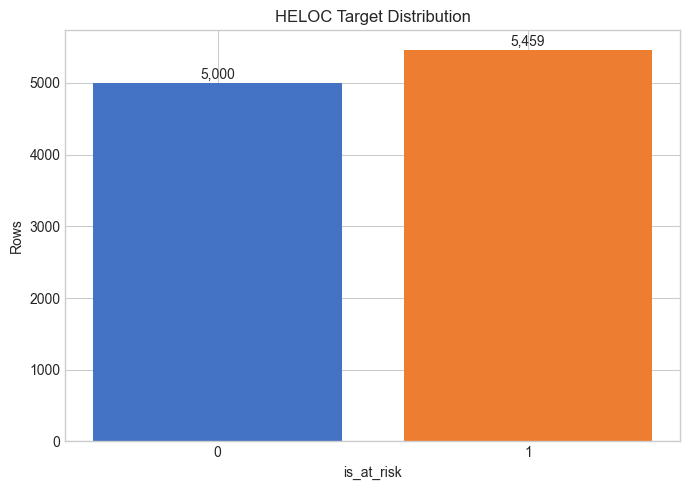

In [5]:
target_distribution = (y.value_counts(dropna=False).sort_index()
    .rename("count").to_frame())
target_distribution["percentage"] = 100 * target_distribution["count"] / len(raw_df)
target_distribution.index.name = "target_value"
target_distribution = target_distribution.reset_index()
target_distribution.to_csv(ARTIFACT_DIR / "target_distribution.csv", index=False)
display(target_distribution)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(target_distribution.target_value.astype(str), target_distribution["count"], color=["#4472C4", "#ED7D31"])
ax.set(title="HELOC Target Distribution", xlabel="is_at_risk", ylabel="Rows")
for bar, count in zip(bars, target_distribution["count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 60, f"{count:,}", ha="center")
fig.tight_layout()
fig.savefig(PLOT_DIR / "heloc_target_distribution.png", dpi=300)
plt.show()

## 6. Missing and special numeric values

Native nulls and negative numeric codes are audited separately. The dataset card does not define the meanings of `-7`, `-8`, or `-9`, so they remain unchanged and are marked for confirmation.

Native missing values: 0
Rows with at least one negative predictor value: 7957


,feature,special_value,count,percentage,semantics
0,estimate_of_risk,-9,598,5.717564,Meaning not defined by loaded DatasetInfo or d...
1,months_since_first_trade,-9,588,5.621952,Meaning not defined by loaded DatasetInfo or d...
2,months_since_first_trade,-8,239,2.285113,Meaning not defined by loaded DatasetInfo or d...
3,months_since_last_trade,-9,588,5.621952,Meaning not defined by loaded DatasetInfo or d...
4,average_duration_of_resolution,-9,588,5.621952,Meaning not defined by loaded DatasetInfo or d...
5,number_of_satisfactory_trades,-9,588,5.621952,Meaning not defined by loaded DatasetInfo or d...
6,nr_trades_insolvent_for_over_60_days,-9,588,5.621952,Meaning not defined by loaded DatasetInfo or d...
7,nr_trades_insolvent_for_over_90_days,-9,588,5.621952,Meaning not defined by loaded DatasetInfo or d...
8,percentage_of_legal_trades,-9,588,5.621952,Meaning not defined by loaded DatasetInfo or d...
9,months_since_last_illegal_trade,-9,588,5.621952,Meaning not defined by loaded DatasetInfo or d...


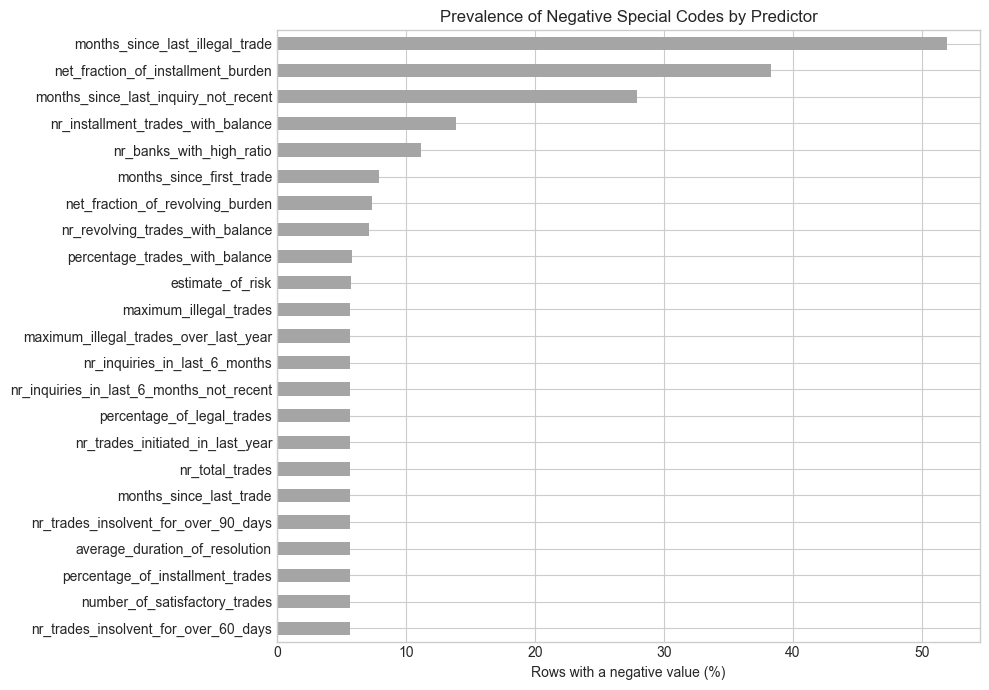

In [6]:
missing_value_audit = pd.DataFrame({
    "feature": raw_df.columns,
    "missing_count": raw_df.isna().sum().values,
    "missing_percentage": 100 * raw_df.isna().sum().values / len(raw_df),
})
missing_value_audit.to_csv(ARTIFACT_DIR / "missing_value_audit.csv", index=False)

special_rows = []
for feature in predictor_columns:
    negative_counts = X.loc[X[feature] < 0, feature].value_counts().sort_index()
    if negative_counts.empty:
        special_rows.append({"feature": feature, "special_value": np.nan, "count": 0,
                             "percentage": 0.0, "semantics": "No negative values observed"})
    else:
        for value, count in negative_counts.items():
            special_rows.append({"feature": feature, "special_value": int(value), "count": int(count),
                                 "percentage": 100 * count / len(raw_df),
                                 "semantics": "Meaning not defined by loaded DatasetInfo or dataset card; confirmation required"})
special_value_audit = pd.DataFrame(special_rows)
special_value_audit.to_csv(ARTIFACT_DIR / "special_value_audit.csv", index=False)

print("Native missing values:", int(raw_df.isna().sum().sum()))
print("Rows with at least one negative predictor value:", int(X.lt(0).any(axis=1).sum()))
display(special_value_audit.loc[special_value_audit["count"].gt(0)])

special_prevalence = (X.lt(0).mean().mul(100).sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(10, 7))
special_prevalence.sort_values().plot.barh(ax=ax, color="#A5A5A5")
ax.set(title="Prevalence of Negative Special Codes by Predictor", xlabel="Rows with a negative value (%)", ylabel="")
fig.tight_layout()
fig.savefig(PLOT_DIR / "heloc_special_value_prevalence.png", dpi=300)
plt.show()

## 7. Duplicate audit

Complete-row duplicates and repeated predictor profiles are retained. Predictor profiles with conflicting targets are reported because they require explicit handling decisions later.

In [7]:
exact_duplicate_rows = int(raw_df.duplicated().sum())
duplicate_predictor_rows = int(X.duplicated().sum())
profile_target_counts = raw_df.groupby(predictor_columns, dropna=False)[TARGET].nunique()
conflicting_predictor_profiles = int(profile_target_counts.gt(1).sum())
all_negative_nine_profiles = int(X.eq(-9).all(axis=1).sum())

duplicate_audit = pd.DataFrame([
    {"check": "exact_duplicate_complete_rows", "count": exact_duplicate_rows},
    {"check": "duplicate_predictor_rows", "count": duplicate_predictor_rows},
    {"check": "unique_predictor_profiles", "count": len(X.drop_duplicates())},
    {"check": "predictor_profiles_with_conflicting_targets", "count": conflicting_predictor_profiles},
    {"check": "rows_with_all_predictors_equal_to_minus_9", "count": all_negative_nine_profiles},
])
duplicate_audit.to_csv(ARTIFACT_DIR / "duplicate_audit.csv", index=False)
display(duplicate_audit)

,check,count
0,exact_duplicate_complete_rows,587
1,duplicate_predictor_rows,588
2,unique_predictor_profiles,9871
3,predictor_profiles_with_conflicting_targets,1
4,rows_with_all_predictors_equal_to_minus_9,588


## 8. Numerical description and feature audit

The descriptive statistics include all negative codes and must not be read as clean continuous summaries. Separate special-value columns make their influence visible.

In [8]:
numerical_statistics = X.describe(percentiles=[0.25, 0.5, 0.75]).T.reset_index(names="feature")
numerical_statistics.to_csv(ARTIFACT_DIR / "numerical_statistics.csv", index=False)

feature_audit_rows = []
for feature in raw_df.columns:
    series = raw_df[feature]
    negatives = sorted(series.loc[series.lt(0)].unique().astype(int).tolist())
    concern = "Target column; retain unchanged in Stage 01" if feature == TARGET else (
        "Negative special codes require semantic confirmation before preprocessing" if negatives else "No immediate data-quality issue identified in Stage 01")
    if feature == "estimate_of_risk":
        concern = "Potential pre-existing risk score or target-proxy; definition and availability timing require review"
    feature_audit_rows.append({
        "raw_feature_name": feature,
        "dtype": str(series.dtype),
        "role": "target" if feature == TARGET else "predictor",
        "missing_count": int(series.isna().sum()),
        "unique_count": int(series.nunique(dropna=False)),
        "minimum": int(series.min()),
        "maximum": int(series.max()),
        "suspected_special_values": ", ".join(map(str, negatives)) if negatives else "none observed",
        "preliminary_interpretation": "Target named is_at_risk" if feature == TARGET else "Meaning inferred only from dataset-card feature name; detailed definition not provided",
        "possible_modelling_concern": concern,
    })
feature_audit = pd.DataFrame(feature_audit_rows)
feature_audit.to_csv(ARTIFACT_DIR / "feature_audit.csv", index=False)
display(feature_audit)
display(numerical_statistics)

,raw_feature_name,dtype,role,missing_count,unique_count,minimum,maximum,suspected_special_values,preliminary_interpretation,possible_modelling_concern
0,estimate_of_risk,int64,predictor,0,61,-9,94,-9,Meaning inferred only from dataset-card featur...,Potential pre-existing risk score or target-pr...
1,months_since_first_trade,int64,predictor,0,526,-9,803,"-9, -8",Meaning inferred only from dataset-card featur...,Negative special codes require semantic confir...
2,months_since_last_trade,int64,predictor,0,112,-9,383,-9,Meaning inferred only from dataset-card featur...,Negative special codes require semantic confir...
3,average_duration_of_resolution,int64,predictor,0,237,-9,383,-9,Meaning inferred only from dataset-card featur...,Negative special codes require semantic confir...
4,number_of_satisfactory_trades,int64,predictor,0,74,-9,79,-9,Meaning inferred only from dataset-card featur...,Negative special codes require semantic confir...
5,nr_trades_insolvent_for_over_60_days,int64,predictor,0,19,-9,19,-9,Meaning inferred only from dataset-card featur...,Negative special codes require semantic confir...
6,nr_trades_insolvent_for_over_90_days,int64,predictor,0,17,-9,19,-9,Meaning inferred only from dataset-card featur...,Negative special codes require semantic confir...
7,percentage_of_legal_trades,int64,predictor,0,72,-9,100,-9,Meaning inferred only from dataset-card featur...,Negative special codes require semantic confir...
8,months_since_last_illegal_trade,int64,predictor,0,87,-9,83,"-9, -8, -7",Meaning inferred only from dataset-card featur...,Negative special codes require semantic confir...
9,maximum_illegal_trades_over_last_year,int64,predictor,0,10,-9,9,-9,Meaning inferred only from dataset-card featur...,Negative special codes require semantic confir...


,feature,count,mean,std,min,25%,50%,75%,max
0,estimate_of_risk,10459.0,67.425758,21.121621,-9.0,63.0,71.0,79.0,94.0
1,months_since_first_trade,10459.0,184.205373,109.683816,-9.0,118.0,178.0,249.5,803.0
2,months_since_last_trade,10459.0,8.543455,13.301745,-9.0,3.0,5.0,11.0,383.0
3,average_duration_of_resolution,10459.0,73.843293,38.782803,-9.0,52.0,74.0,95.0,383.0
4,number_of_satisfactory_trades,10459.0,19.428052,13.004327,-9.0,12.0,19.0,27.0,79.0
5,nr_trades_insolvent_for_over_60_days,10459.0,0.042738,2.513910,-9.0,0.0,0.0,1.0,19.0
6,nr_trades_insolvent_for_over_90_days,10459.0,-0.142843,2.367397,-9.0,0.0,0.0,0.0,19.0
7,percentage_of_legal_trades,10459.0,86.661536,25.999584,-9.0,87.0,96.0,100.0,100.0
8,months_since_last_illegal_trade,10459.0,6.762406,20.501250,-9.0,-7.0,-7.0,14.0,83.0
9,maximum_illegal_trades_over_last_year,10459.0,4.928291,3.756275,-9.0,4.0,6.0,7.0,9.0


## 9. Selected numerical distributions

Four interpretable credit-history measures are shown without altering special codes. Values below zero are visible rather than silently treated as continuous observations.

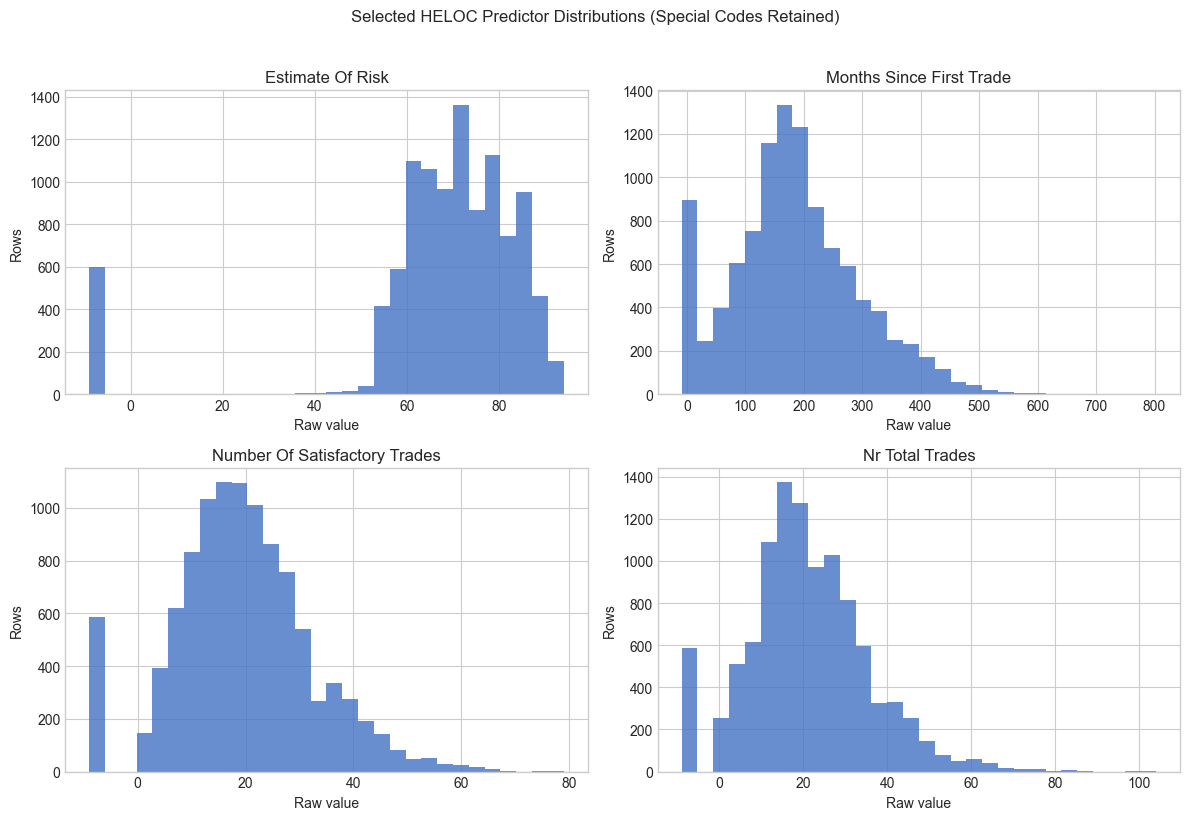

In [9]:
selected_features = [
    "estimate_of_risk", "months_since_first_trade",
    "number_of_satisfactory_trades", "nr_total_trades",
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for feature, ax in zip(selected_features, axes.flat):
    ax.hist(raw_df[feature], bins=30, color="#4472C4", alpha=0.8)
    ax.set(title=feature.replace("_", " ").title(), xlabel="Raw value", ylabel="Rows")
fig.suptitle("Selected HELOC Predictor Distributions (Special Codes Retained)", y=1.02)
fig.tight_layout()
fig.savefig(PLOT_DIR / "heloc_selected_predictor_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Selected distributions by target

Boxplots provide a descriptive comparison only. They include negative codes, so apparent differences require careful interpretation.

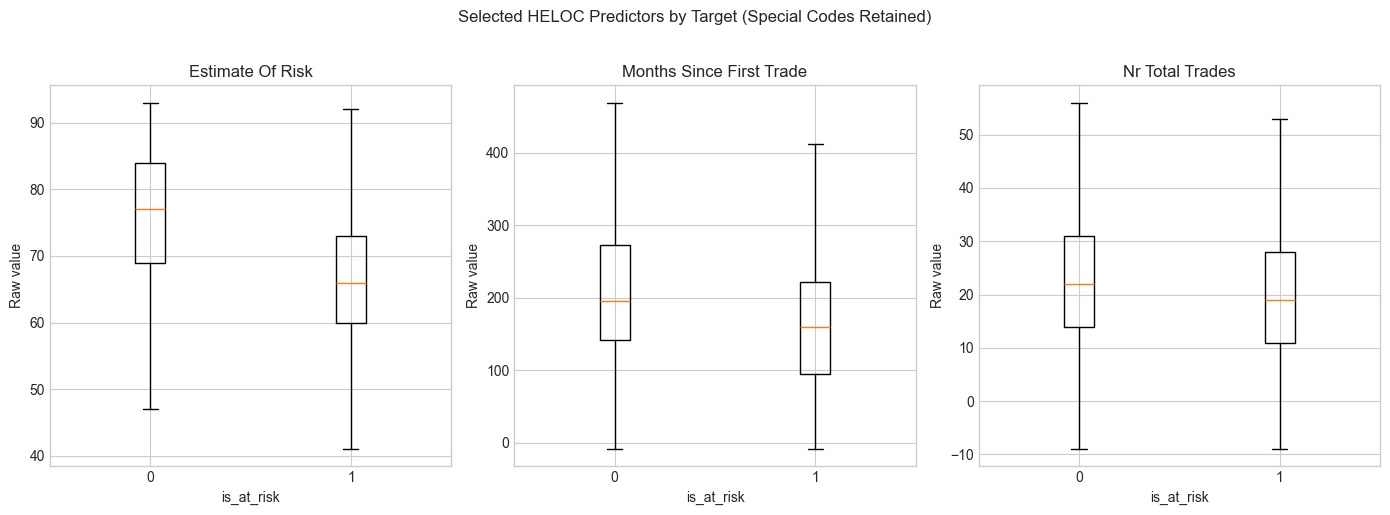

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for feature, ax in zip(["estimate_of_risk", "months_since_first_trade", "nr_total_trades"], axes):
    groups = [raw_df.loc[y.eq(value), feature] for value in sorted(y.unique())]
    ax.boxplot(groups, tick_labels=[str(value) for value in sorted(y.unique())], showfliers=False)
    ax.set(title=feature.replace("_", " ").title(), xlabel="is_at_risk", ylabel="Raw value")
fig.suptitle("Selected HELOC Predictors by Target (Special Codes Retained)", y=1.02)
fig.tight_layout()
fig.savefig(PLOT_DIR / "heloc_selected_predictors_by_target.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Sensitive/proxy and leakage review

No explicit demographic attribute is documented in the loaded schema. Credit-history variables may still act as socioeconomic proxies, while `estimate_of_risk` requires particular review as a possible pre-existing score or target proxy.

In [11]:
sensitive_proxy_audit = pd.DataFrame([
    {
        "scope": "all documented predictors",
        "finding": "No explicit protected demographic attribute is named in the loaded schema or dataset card",
        "status": "No direct sensitive attribute verified; proxy effects still require later empirical review",
    },
    {
        "scope": "credit history, burden, balance and inquiry variables",
        "finding": "Financial-history measures may correlate with socioeconomic circumstances",
        "status": "Possible proxy concern; requires fairness review before interpretation or deployment claims",
    },
])
sensitive_proxy_audit.to_csv(ARTIFACT_DIR / "sensitive_proxy_audit.csv", index=False)

leakage_audit = pd.DataFrame([
    {
        "feature_or_scope": "estimate_of_risk",
        "finding": "Name suggests an existing risk estimate, but its construction is not documented by the loaded source",
        "stage_02_review": "Confirm definition, calculation time and whether it encodes the outcome or another model score",
    },
    {
        "feature_or_scope": "remaining credit-report predictors",
        "finding": "No obvious post-outcome variable is verified from the available names alone",
        "stage_02_review": "Confirm definitions and availability at application decision time",
    },
])
leakage_audit.to_csv(ARTIFACT_DIR / "leakage_audit.csv", index=False)
display(sensitive_proxy_audit)
display(leakage_audit)

,scope,finding,status
0,all documented predictors,No explicit protected demographic attribute is...,No direct sensitive attribute verified; proxy ...
1,"credit history, burden, balance and inquiry va...",Financial-history measures may correlate with ...,Possible proxy concern; requires fairness revi...


,feature_or_scope,finding,stage_02_review
0,estimate_of_risk,"Name suggests an existing risk estimate, but i...","Confirm definition, calculation time and wheth..."
1,remaining credit-report predictors,No obvious post-outcome variable is verified f...,Confirm definitions and availability at applic...


## 12. Provenance and dataset summary

Only metadata exposed by the loaded library object and the dataset repository is recorded. Missing descriptive metadata is left blank rather than inferred.

In [12]:
download_sources = list((source_dataset.info.download_checksums or {}).keys())
source_revision = None
if download_sources and "@" in download_sources[0]:
    source_revision = download_sources[0].split("@")[1].split("/")[0]

dataset_provenance = {
    "dataset_number": 3,
    "source_identifier": SOURCE_ID,
    "acquisition_call": 'load_dataset("mstz/heloc")',
    "dataset_name": source_dataset.info.dataset_name,
    "config_name": source_dataset.info.config_name,
    "version": str(source_dataset.info.version),
    "available_splits": split_inventory.to_dict(orient="records"),
    "split_used": "train",
    "row_count": len(raw_df),
    "column_count": raw_df.shape[1],
    "feature_names": raw_df.columns.tolist(),
    "feature_schema": {name: str(value) for name, value in source_dataset.features.items()},
    "target_column": TARGET,
    "observed_target_values": sorted(y.unique().astype(int).tolist()),
    "builder_name": source_dataset.info.builder_name,
    "source_revision_from_download_uri": source_revision,
    "download_sources": download_sources,
    "description": source_dataset.info.description or None,
    "citation": source_dataset.info.citation or None,
    "homepage": source_dataset.info.homepage or None,
    "license_from_dataset_info": source_dataset.info.license or None,
    "raw_snapshot": str(SNAPSHOT_PATH.relative_to(PROJECT_ROOT)),
    "raw_snapshot_sha256": snapshot_sha256,
    "snapshot_row_count": len(persisted_df),
    "retrieved_at_utc": datetime.now(timezone.utc).isoformat(),
}
with open(ARTIFACT_DIR / "dataset_provenance.json", "w", encoding="utf-8") as handle:
    json.dump(dataset_provenance, handle, indent=2)

dataset_summary = {
    "rows": len(raw_df), "columns": raw_df.shape[1], "predictor_count": len(predictor_columns),
    "numeric_predictor_count": int(X.select_dtypes(include=np.number).shape[1]),
    "categorical_predictor_count": int(X.select_dtypes(exclude=np.number).shape[1]),
    "target_column": TARGET,
    "target_distribution": target_distribution.to_dict(orient="records"),
    "native_missing_values": int(raw_df.isna().sum().sum()),
    "rows_with_negative_predictor_codes": int(X.lt(0).any(axis=1).sum()),
    "observed_negative_codes": sorted(pd.unique(X.where(X.lt(0)).stack()).astype(int).tolist()),
    "exact_duplicate_complete_rows": exact_duplicate_rows,
    "duplicate_predictor_rows": duplicate_predictor_rows,
    "conflicting_predictor_profiles": conflicting_predictor_profiles,
    "all_minus_9_predictor_rows": all_negative_nine_profiles,
    "descriptive_statistics_include_special_codes": True,
    "special_code_semantics_verified": False,
}
with open(ARTIFACT_DIR / "dataset_summary.json", "w", encoding="utf-8") as handle:
    json.dump(dataset_summary, handle, indent=2)
display(pd.DataFrame([dataset_summary]))

,rows,columns,predictor_count,numeric_predictor_count,categorical_predictor_count,target_column,target_distribution,native_missing_values,rows_with_negative_predictor_codes,observed_negative_codes,exact_duplicate_complete_rows,duplicate_predictor_rows,conflicting_predictor_profiles,all_minus_9_predictor_rows,descriptive_statistics_include_special_codes,special_code_semantics_verified
0,10459,24,23,23,0,is_at_risk,"[{'target_value': 0, 'count': 5000, 'percentag...",0,7957,"[-9, -8, -7]",587,588,1,588,True,False


## 13. Quality checks

The checks confirm that the source rows, snapshot, target totals and Stage 01 artifacts remain complete.

In [13]:
assert len(raw_df) == 10_459
assert raw_df.shape[1] == 24
assert len(predictor_columns) == 23
assert TARGET in raw_df.columns
assert set(y.unique()) == {0, 1}
assert target_distribution["count"].sum() == len(raw_df)
assert len(persisted_df) == len(raw_df)
pd.testing.assert_frame_equal(persisted_df, raw_df, check_dtype=False)
assert hashlib.sha256(SNAPSHOT_PATH.read_bytes()).hexdigest() == snapshot_sha256
assert len(feature_audit) == raw_df.shape[1]
assert len(missing_value_audit) == raw_df.shape[1]
assert not special_value_audit.empty

print("Source rows:", len(raw_df))
print("Snapshot rows:", len(persisted_df))
print("Snapshot SHA-256 verified:", True)
print("Target rows accounted for:", int(target_distribution["count"].sum()))
print("Rows removed:", 0)
print("Preprocessing performed: False")
print("Train/test split created: False")
print("Model trained: False")
print("XAI performed: False")

Source rows: 10459
Snapshot rows: 10459
Snapshot SHA-256 verified: True
Target rows accounted for: 10459
Rows removed: 0
Preprocessing performed: False
Train/test split created: False
Model trained: False
XAI performed: False


## 14. Decisions required before Stage 02

The meanings of `-7`, `-8`, and `-9` need an authoritative source before missing-value treatment is chosen. The 588 all-`-9` predictor rows, duplicated profiles with conflicting targets, and the definition and timing of `estimate_of_risk` also need review. No decision is made here.